In [1]:
import os, shutil
import torch
import kagglehub
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

path = kagglehub.dataset_download("emmarex/plantdisease")
data_dir = os.path.join(path, "PlantVillage")

dup = os.path.join(data_dir, "PlantVillage")
if os.path.exists(dup):
    shutil.rmtree(dup)

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness = 0.2, contrast = 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean,std)
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_full = datasets.ImageFolder(data_dir, transform = train_transform)
test_full = datasets.ImageFolder(data_dir, transform = test_transform)

train_size = int(0.8 * len(train_full))
generator = torch.Generator().manual_seed(42)
indices = torch.randperm(len(train_full), generator = generator).tolist()

train_data = Subset(train_full, indices[:train_size])
test_data = Subset(test_full, indices[train_size:])

train_loader = DataLoader(train_data, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_data, batch_size = 32)

classes = train_full.classes
print(len(train_data), len(test_data), len(classes))

c:\Users\bryan\Documents\Github\Repositories\Leaf-Disease-Detector\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


16510 4128 15


In [2]:
import torch.nn as nn
from torchvision import models

device = "cuda"

weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights = weights)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, len(classes))
model = model.to(device)

print(model.fc)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total:,} | trainable: {trainable:,}")

Linear(in_features=512, out_features=15, bias=True)
Total params: 11,184,207 | trainable: 7,695


In [3]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss = 0
    for images, labels in tqdm(loader, desc = "Training"):
        images, labels = images.to(device), labels.to(device)
        output = model(images)
        loss = loss_fn(output, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(dim = 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total
            

In [5]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr = 0.0001)

for epoch in range(5):
    loss = train_one_epoch(model, train_loader, optimizer, loss_fn)
    test_acc = evaluate(model, test_loader)
    print(f"Epoch {epoch + 1}: loss {loss:.3f} | test acc {test_acc:.2%}")

Training: 100%|██████████| 516/516 [00:43<00:00, 11.87it/s]


Epoch 1: loss 0.362 | test acc 89.73%


Training: 100%|██████████| 516/516 [00:46<00:00, 11.06it/s]


Epoch 2: loss 0.360 | test acc 89.22%


Training: 100%|██████████| 516/516 [00:45<00:00, 11.38it/s]


Epoch 3: loss 0.349 | test acc 89.53%


Training: 100%|██████████| 516/516 [00:48<00:00, 10.53it/s]


Epoch 4: loss 0.352 | test acc 89.49%


Training: 100%|██████████| 516/516 [00:50<00:00, 10.26it/s]


Epoch 5: loss 0.342 | test acc 89.75%


In [6]:
torch.save(model.state_dict(), "../models/resnet_frozen.pth")

We trained our own model, and it resulted an accuracy of 95%. We then trained a pre-trained model because I thought "pre-trained model is always better" but that's not true. Frozen transfer learning isn't automatically better. It may learned a lot of images, but it wasn't tuned for subtle stuff like tiny brown spots vs yellow curling for our leaf disease detector. 

In [7]:
for param in model.parameters():
    param.requires_grad = True
optimizer = torch.optim.Adam(model.parameters(), lr = 0.0001)

for epoch in range(5):
    loss = train_one_epoch(model, train_loader, optimizer, loss_fn)
    test_acc = evaluate(model, test_loader)
    print(f"Epoch {epoch + 1}: loss {loss:.3f} | test acc {test_acc:.2%}")

Training: 100%|██████████| 516/516 [01:00<00:00,  8.55it/s]


Epoch 1: loss 0.193 | test acc 96.97%


Training: 100%|██████████| 516/516 [01:00<00:00,  8.59it/s]


Epoch 2: loss 0.090 | test acc 98.18%


Training: 100%|██████████| 516/516 [01:03<00:00,  8.12it/s]


Epoch 3: loss 0.057 | test acc 97.99%


Training: 100%|██████████| 516/516 [01:03<00:00,  8.17it/s]


Epoch 4: loss 0.056 | test acc 98.86%


Training: 100%|██████████| 516/516 [01:02<00:00,  8.20it/s]


Epoch 5: loss 0.041 | test acc 99.06%


In [8]:
torch.save(model.state_dict(), "../models/resnet_finetuned.pth")

Per-class evaluation.
Reload the fine-tuned model from disk (no retraining needed)

In [2]:
import torch.nn as nn
from torchvision import models

device = "cuda"

model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(classes))
model.load_state_dict(torch.load("../models/resnet_finetuned.pth"))
model = model.to(device)

In [3]:
all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds = model(images).argmax(dim = 1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.tolist())

print(len(all_preds))

4128


In [4]:
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names = classes, digits = 3))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot      0.995     1.000     0.997       188
                     Pepper__bell___healthy      1.000     0.997     0.998       307
                      Potato___Early_blight      1.000     0.991     0.995       214
                       Potato___Late_blight      0.995     0.981     0.988       211
                           Potato___healthy      0.909     1.000     0.952        30
                      Tomato_Bacterial_spot      0.982     1.000     0.991       448
                        Tomato_Early_blight      0.955     0.964     0.959       196
                         Tomato_Late_blight      0.994     0.975     0.985       361
                           Tomato_Leaf_Mold      0.995     0.984     0.989       191
                  Tomato_Septoria_leaf_spot      0.983     0.989     0.986       349
Tomato_Spider_mites_Two_spotted_spider_mite      0.991     0.985

In [5]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

mistakes = []

for true_idx in range(len(classes)):
    for pred_idx in range(len(classes)):
        if true_idx != pred_idx and cm[true_idx, pred_idx] > 0:
            mistakes.append((cm[true_idx, pred_idx], classes[true_idx], classes[pred_idx]))
for count, true_c, pred_c in sorted(mistakes, reverse = True):
    print(f"{count:3d} {true_c} -> predicted as {pred_c}")

  6 Tomato_Late_blight -> predicted as Tomato_Early_blight
  4 Tomato_Early_blight -> predicted as Tomato_Bacterial_spot
  3 Tomato_Septoria_leaf_spot -> predicted as Tomato_Bacterial_spot
  3 Potato___Late_blight -> predicted as Potato___healthy
  2 Tomato__Target_Spot -> predicted as Tomato_Early_blight
  2 Tomato_Spider_mites_Two_spotted_spider_mite -> predicted as Tomato__Target_Spot
  2 Tomato_Spider_mites_Two_spotted_spider_mite -> predicted as Tomato_Septoria_leaf_spot
  2 Tomato_Leaf_Mold -> predicted as Tomato_Septoria_leaf_spot
  1 Tomato__Target_Spot -> predicted as Tomato_Spider_mites_Two_spotted_spider_mite
  1 Tomato__Target_Spot -> predicted as Tomato_Septoria_leaf_spot
  1 Tomato_Spider_mites_Two_spotted_spider_mite -> predicted as Tomato__Tomato_YellowLeaf__Curl_Virus
  1 Tomato_Septoria_leaf_spot -> predicted as Tomato_Late_blight
  1 Tomato_Leaf_Mold -> predicted as Tomato_Spider_mites_Two_spotted_spider_mite
  1 Tomato_Late_blight -> predicted as Tomato__Tomato_Yell

Grad-CAM
We want to know further if the model is predicting based on the disease spots or the image background

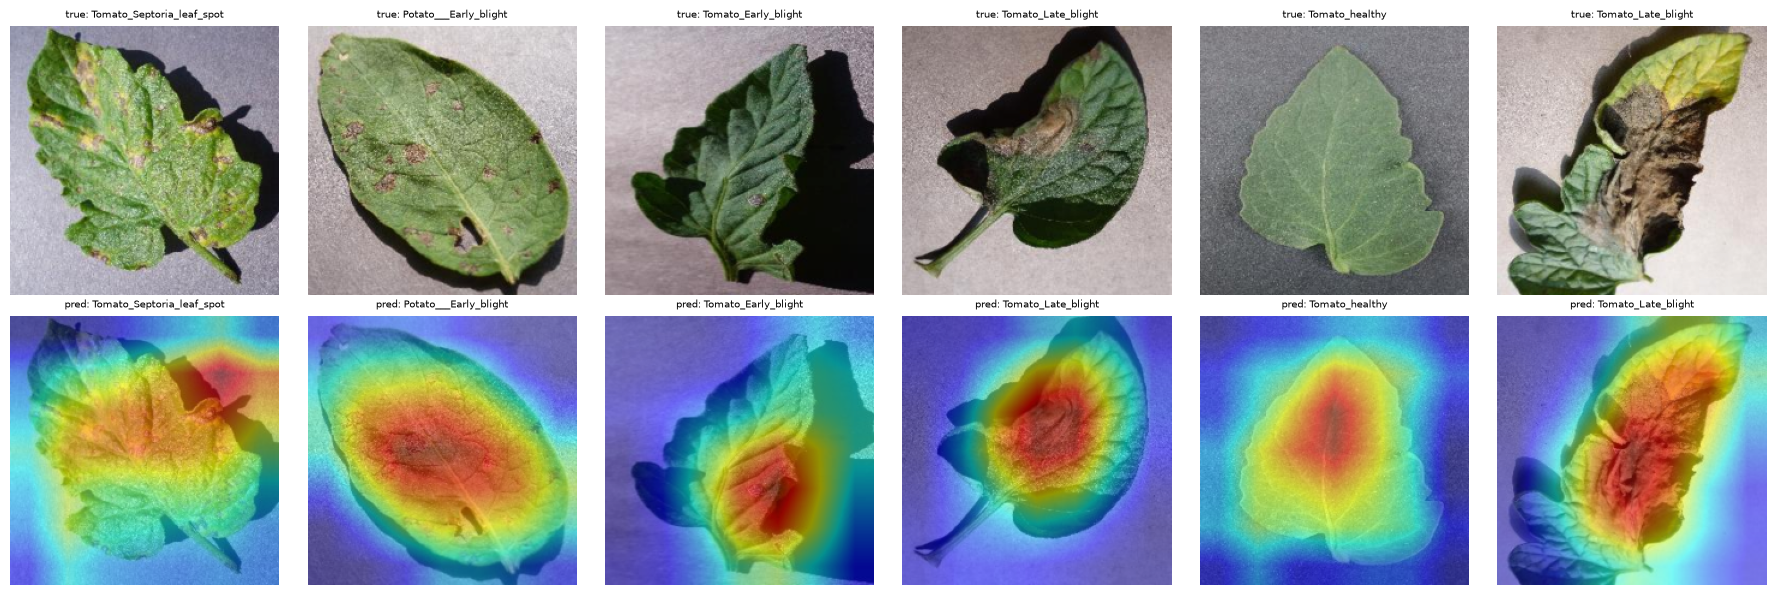

In [8]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import numpy as np
import matplotlib.pyplot as plt

model.eval()
cam = GradCAM(model = model, target_layers = [model.layer4[-1]])

def denormalize(img):
    img = img.permute(1, 2, 0).cpu().numpy()
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)
images, labels = next(iter(test_loader))
images = images[:6].to(device)
labels = labels[:6]

with torch.no_grad():
    preds = model(images).argmax(dim = 1).cpu()
targets = [ClassifierOutputTarget(p.item()) for p in preds]
heatmaps = cam(input_tensor = images, targets = targets)

fig, axes = plt.subplots(2, 6, figsize = (18, 6))
for i in range(6):
    rgb = denormalize(images[i])
    overlay = show_cam_on_image(rgb.astype(np.float32), heatmaps[i], use_rgb = True)

    axes[0, i].imshow(rgb)
    axes[0, i].set_title(f"true: {classes[labels[i]]}", fontsize=7)
    axes[1, i].imshow(overlay)
    axes[1, i].set_title(f"pred: {classes[preds[i]]}", fontsize=7)
    axes[0, i].axis("off")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

In [9]:
fig.savefig("../gradcam_examples.png", dpi=150, bbox_inches="tight")

Found 3 cases


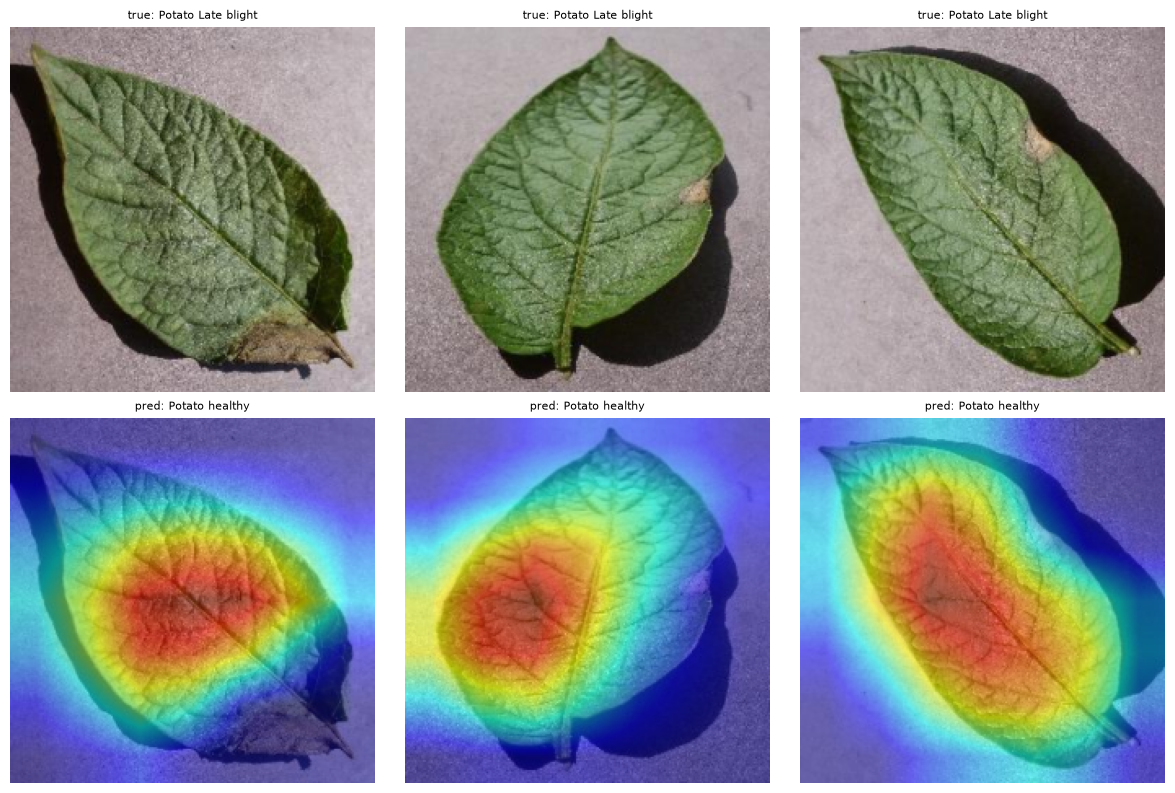

In [10]:
lb = classes.index("Potato___Late_blight")
healthy = classes.index("Potato___healthy")

bad = [i for i in range(len(all_labels)) if all_labels[i] == lb and all_preds[i] == healthy]
print(f"Found {len(bad)} cases")

imgs = torch.stack([test_data[i][0] for i in bad]).to(device)
targets = [ClassifierOutputTarget(healthy) for _ in bad]
heatmaps = cam(input_tensor=imgs, targets=targets)

fig, axes = plt.subplots(2, len(bad), figsize=(4 * len(bad), 8), squeeze=False)
for j in range(len(bad)):
    rgb = denormalize(imgs[j])
    axes[0, j].imshow(rgb)
    axes[0, j].set_title("true: Potato Late blight", fontsize=8)
    axes[1, j].imshow(show_cam_on_image(rgb.astype(np.float32), heatmaps[j], use_rgb=True))
    axes[1, j].set_title("pred: Potato healthy", fontsize=8)
    axes[0, j].axis("off")
    axes[1, j].axis("off")
plt.tight_layout()
plt.show()

In [11]:
fig.savefig("../gradcam_critical_errors.png", dpi=150, bbox_inches="tight")